# Galaxy Zoo Morphology Prediction

This notebook trains and compares two models for the Galaxy Zoo Kaggle dataset:

1. **Mean-label baseline**: predicts the average 37-dimensional label vector.
2. **Custom CNN baseline**: trained from scratch on galaxy images.
3. **EfficientNet-B0 transfer learning model**: uses an ImageNet-pretrained backbone.

The task is treated as **multi-output regression**: each image is mapped to a vector of **37 probabilistic Galaxy Zoo morphology outputs**. The evaluation metric is **global RMSE** over all test images and all 37 outputs.

The notebook is designed so that the custom CNN is loaded from a saved model if available. If the saved model is missing, it trains from scratch.


## 1. Mount Google Drive

The Kaggle zip files should be stored in one of these Drive folders:

```text
/content/drive/MyDrive/galaxy_zoo/
```

or

```text
/content/drive/MyDrive/galaxyzoo/
```

Required files:

```text
images_training_rev1.zip
training_solutions_rev1.zip
```


In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## 2. Imports, configuration, and device check


In [2]:
from pathlib import Path
import os
import zipfile
import json
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: NVIDIA A100-SXM4-40GB


## 3. Locate and extract the dataset

The zip files are kept in Google Drive. They are extracted to `/content/galaxy_zoo`, which is faster for training than reading images directly from Drive.


In [3]:
DRIVE_CANDIDATES = [
    Path("/content/drive/MyDrive/galaxy_zoo"),
    Path("/content/drive/MyDrive/galaxyzoo"),
]

DRIVE_DATA_DIR = None
for candidate in DRIVE_CANDIDATES:
    if candidate.exists():
        DRIVE_DATA_DIR = candidate
        break

if DRIVE_DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the Drive data folder. Create either MyDrive/galaxy_zoo or MyDrive/galaxyzoo and upload the zip files there."
    )

print("Using Drive data folder:", DRIVE_DATA_DIR)

EXTRACT_DIR = Path("/content/galaxy_zoo")
EXTRACT_DIR.mkdir(exist_ok=True)

train_zip = DRIVE_DATA_DIR / "images_training_rev1.zip"
labels_zip = DRIVE_DATA_DIR / "training_solutions_rev1.zip"

if not train_zip.exists():
    raise FileNotFoundError(f"Missing {train_zip}")
if not labels_zip.exists():
    raise FileNotFoundError(f"Missing {labels_zip}")

# Extract labels if needed
csv_direct = EXTRACT_DIR / "training_solutions_rev1.csv"
if not csv_direct.exists():
    print("Extracting labels...")
    with zipfile.ZipFile(labels_zip, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
else:
    print("Labels already extracted.")

# Extract images if needed
image_dir = EXTRACT_DIR / "images_training_rev1"
if not image_dir.exists() or len(list(image_dir.glob("*.jpg"))) == 0:
    print("Extracting training images. This may take a few minutes...")
    with zipfile.ZipFile(train_zip, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
else:
    print("Training images already extracted.")

CSV_PATH = EXTRACT_DIR / "training_solutions_rev1.csv"
IMAGE_DIR = EXTRACT_DIR / "images_training_rev1"

print("CSV exists:", CSV_PATH.exists(), CSV_PATH)
print("Image folder exists:", IMAGE_DIR.exists(), IMAGE_DIR)
print("Number of jpg images:", len(list(IMAGE_DIR.glob("*.jpg"))))


Using Drive data folder: /content/drive/MyDrive/galaxyzoo
Extracting labels...
Extracting training images. This may take a few minutes...
CSV exists: True /content/galaxy_zoo/training_solutions_rev1.csv
Image folder exists: True /content/galaxy_zoo/images_training_rev1
Number of jpg images: 61578


## 4. Load labels and inspect the target vector

Each row contains one `GalaxyID` and 37 probabilistic morphology outputs. These 37 values are the regression targets.


In [4]:
df = pd.read_csv(CSV_PATH)
label_cols = [col for col in df.columns if col != "GalaxyID"]

print("Dataframe shape:", df.shape)
print("Number of label columns:", len(label_cols))
display(df.head())

assert len(label_cols) == 37, "Expected 37 output columns."

row = df.iloc[0]
example_id = int(row["GalaxyID"])
example_vector = row[label_cols].values.astype("float32")

print("Example GalaxyID:", example_id)
print("Label vector shape:", example_vector.shape)
print("First 10 label values:", np.round(example_vector[:10], 3))
print("Label min/max:", example_vector.min(), example_vector.max())
print("Matching image exists:", (IMAGE_DIR / f"{example_id}.jpg").exists())


Dataframe shape: (61578, 38)
Number of label columns: 37


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


Example GalaxyID: 100008
Label vector shape: (37,)
First 10 label values: [0.383 0.617 0.    0.    0.617 0.038 0.578 0.418 0.198 0.   ]
Label min/max: 0.0 0.945547
Matching image exists: True


## 5. Create output folders

Figures, tables, and saved models are written to Google Drive so they remain available if Colab disconnects.


In [5]:
OUTPUT_DIR = DRIVE_DATA_DIR / "project_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
TABLE_DIR = OUTPUT_DIR / "tables"

for folder in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUTPUT_DIR)


Output folder: /content/drive/MyDrive/galaxyzoo/project_outputs


## 6. Figure 1: example galaxy images

This figure is used in the report to show representative images from the training data.


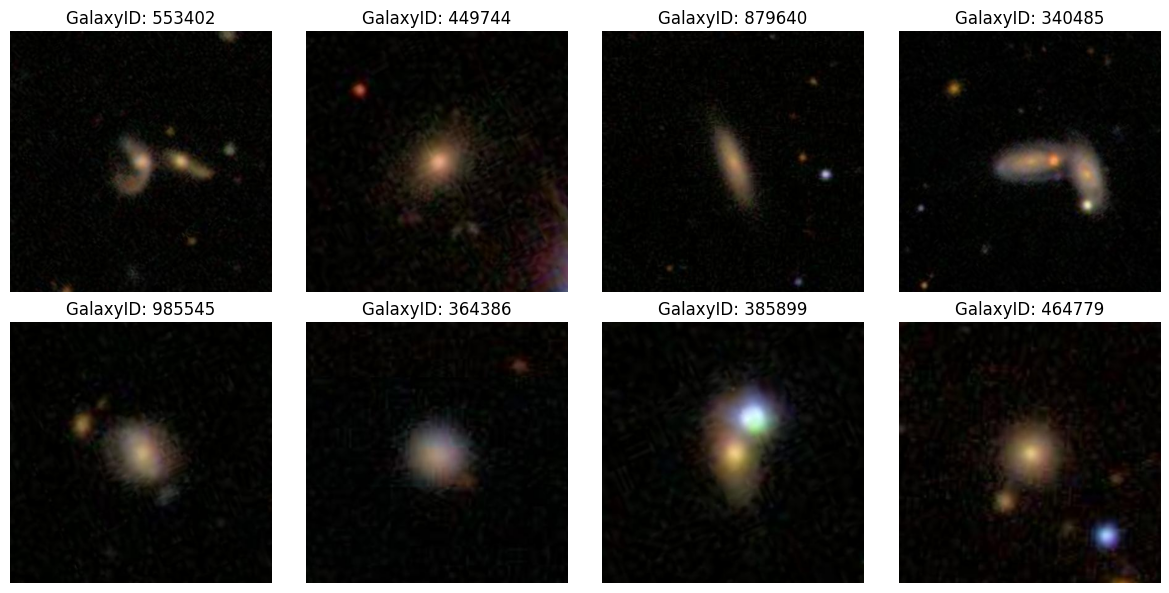

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_example_galaxy_images.png


In [6]:
def save_example_image_grid(df, image_dir, save_path, n=8, seed=42):
    sample = df.sample(n, random_state=seed)
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample.iterrows()):
        galaxy_id = int(row["GalaxyID"])
        img = Image.open(image_dir / f"{galaxy_id}.jpg").convert("RGB")
        ax.imshow(img)
        ax.set_title(f"GalaxyID: {galaxy_id}")
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

example_grid_path = FIG_DIR / "figure_example_galaxy_images.png"
save_example_image_grid(df, IMAGE_DIR, example_grid_path)
print("Saved:", example_grid_path)


## 7. Train/validation/test split

The Kaggle test images do not include labels, so the labelled training data is split into:

- 70% training
- 15% validation
- 15% held-out test


In [7]:
indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
)

print("Train size:", len(train_idx))
print("Validation size:", len(val_idx))
print("Test size:", len(test_idx))

split_info = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_images": [len(train_idx), len(val_idx), len(test_idx)],
    "fraction": [len(train_idx)/len(df), len(val_idx)/len(df), len(test_idx)/len(df)],
})
display(split_info)
split_info.to_csv(TABLE_DIR / "data_split.csv", index=False)


Train size: 43104
Validation size: 9237
Test size: 9237


,split,n_images,fraction
0,train,43104,0.699990
1,validation,9237,0.150005
2,test,9237,0.150005


## 8. PyTorch Dataset and DataLoaders


In [8]:
class GalaxyZooDataset(Dataset):
    def __init__(self, dataframe, image_dir, indices, label_cols, transform=None):
        self.df = dataframe.iloc[indices].reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        galaxy_id = int(row["GalaxyID"])
        image_path = self.image_dir / f"{galaxy_id}.jpg"

        image = Image.open(image_path).convert("RGB")
        labels = row[self.label_cols].values.astype("float32")
        labels = torch.tensor(labels, dtype=torch.float32)

        if self.transform is not None:
            image = self.transform(image)

        return image, labels


## 9. Custom CNN data pipeline

The custom CNN uses 128×128 images without ImageNet normalization, because it is trained from scratch.


In [9]:
CUSTOM_IMG_SIZE = 128
CUSTOM_BATCH_SIZE = 32

custom_train_transform = transforms.Compose([
    transforms.Resize((CUSTOM_IMG_SIZE, CUSTOM_IMG_SIZE)),
    transforms.ToTensor(),
])

custom_eval_transform = transforms.Compose([
    transforms.Resize((CUSTOM_IMG_SIZE, CUSTOM_IMG_SIZE)),
    transforms.ToTensor(),
])

custom_train_dataset = GalaxyZooDataset(df, IMAGE_DIR, train_idx, label_cols, transform=custom_train_transform)
custom_val_dataset = GalaxyZooDataset(df, IMAGE_DIR, val_idx, label_cols, transform=custom_eval_transform)
custom_test_dataset = GalaxyZooDataset(df, IMAGE_DIR, test_idx, label_cols, transform=custom_eval_transform)

custom_train_loader = DataLoader(custom_train_dataset, batch_size=CUSTOM_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
custom_val_loader = DataLoader(custom_val_dataset, batch_size=CUSTOM_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
custom_test_loader = DataLoader(custom_test_dataset, batch_size=CUSTOM_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(custom_train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image min/max:", images.min().item(), images.max().item())
print("Label min/max:", labels.min().item(), labels.max().item())


Image batch shape: torch.Size([32, 3, 128, 128])
Label batch shape: torch.Size([32, 37])
Image min/max: 0.0 1.0
Label min/max: 0.0 1.0


## 10. Training and evaluation helper functions

`evaluate_global_rmse` computes the final report metric over all images and all 37 outputs.


In [10]:
def batch_rmse(preds, targets):
    return torch.sqrt(torch.mean((preds - targets) ** 2))


def train_one_epoch(model, loader, optimizer, loss_fn, device, use_amp=True):
    model.train()
    total_loss = 0.0
    total_rmse = 0.0

    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == "cuda"))

    for images, labels in tqdm(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
            preds = model(images)
            loss = loss_fn(preds, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_rmse += batch_rmse(preds.detach(), labels).item()

    return total_loss / len(loader), total_rmse / len(loader)


@torch.no_grad()
def evaluate_batch_average(model, loader, loss_fn, device, use_amp=True):
    model.eval()
    total_loss = 0.0
    total_rmse = 0.0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
            preds = model(images)
            loss = loss_fn(preds, labels)

        total_loss += loss.item()
        total_rmse += batch_rmse(preds, labels).item()

    return total_loss / len(loader), total_rmse / len(loader)


@torch.no_grad()
def evaluate_global_rmse(model, loader, device, use_amp=True):
    model.eval()
    total_squared_error = 0.0
    total_count = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
            preds = model(images)

        total_squared_error += ((preds.float() - labels.float()) ** 2).sum().item()
        total_count += labels.numel()

    return float(np.sqrt(total_squared_error / total_count))


@torch.no_grad()
def collect_predictions(model, loader, device, max_batches=None, use_amp=True):
    model.eval()
    all_preds = []
    all_labels = []

    for batch_i, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_i >= max_batches:
            break
        images = images.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):
            preds = model(images).detach().cpu()

        all_preds.append(preds)
        all_labels.append(labels.detach().cpu())

    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


## 11. Mean-label baseline

This baseline ignores the image and always predicts the average training-set label vector. It is used to show that the CNNs learn from image information.


In [11]:
def evaluate_mean_baseline(loader, mean_label, device):
    total_squared_error = 0.0
    total_count = 0

    for _, labels in loader:
        labels = labels.to(device)
        preds = mean_label.unsqueeze(0).repeat(labels.size(0), 1)
        total_squared_error += ((preds - labels) ** 2).sum().item()
        total_count += labels.numel()

    return float(np.sqrt(total_squared_error / total_count))

train_labels_np = df.iloc[train_idx][label_cols].values.astype("float32")
mean_label = torch.tensor(train_labels_np.mean(axis=0), dtype=torch.float32).to(DEVICE)

mean_baseline_rmse = evaluate_mean_baseline(custom_test_loader, mean_label, DEVICE)
print("Mean-label baseline global test RMSE:", mean_baseline_rmse)


Mean-label baseline global test RMSE: 0.16370787785127297


## 12. Custom CNN model

The final layer has 37 outputs and a sigmoid activation to keep predictions between 0 and 1.


In [12]:
class CustomCNN(nn.Module):
    def __init__(self, output_dim=37):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x


## 13. Load or train the custom CNN

This cell checks for an existing saved custom CNN. If found, it loads the weights. If not, it trains from scratch and saves the weights.


In [13]:
CUSTOM_CNN_PATHS_TO_CHECK = [
    MODEL_DIR / "custom_cnn_baseline.pth",
    DRIVE_DATA_DIR / "custom_cnn_baseline.pth",
    Path("/content/drive/MyDrive/galaxy_zoo/custom_cnn_baseline.pth"),
    Path("/content/drive/MyDrive/galaxyzoo/custom_cnn_baseline.pth"),
]

custom_cnn_path = MODEL_DIR / "custom_cnn_baseline.pth"
custom_history_path = TABLE_DIR / "custom_cnn_history.csv"

custom_model = CustomCNN(output_dim=37).to(DEVICE)
loss_fn = nn.MSELoss()

existing_custom_path = None
for path in CUSTOM_CNN_PATHS_TO_CHECK:
    if path.exists():
        existing_custom_path = path
        break

if existing_custom_path is not None:
    print("Loading existing custom CNN weights from:", existing_custom_path)
    custom_model.load_state_dict(torch.load(existing_custom_path, map_location=DEVICE))
    custom_model.eval()

    # Copy into the organized output folder if needed.
    if existing_custom_path != custom_cnn_path:
        torch.save(custom_model.state_dict(), custom_cnn_path)
        print("Copied custom CNN weights to:", custom_cnn_path)

    custom_history = None
    if custom_history_path.exists():
        custom_history = pd.read_csv(custom_history_path)
        print("Loaded custom CNN history from:", custom_history_path)
    else:
        # Fallback values from the already recorded 15-epoch run in this project.
        # If you retrain the model later, this file will be replaced by a fresh history CSV.
        custom_history = pd.DataFrame({
            "epoch": list(range(1, 16)),
            "train_rmse": [0.1624, 0.1420, 0.1364, 0.1316, 0.1233, 0.1179, 0.1141, 0.1118, 0.1098, 0.1084, 0.1071, 0.1060, 0.1049, 0.1041, 0.1030],
            "val_rmse":   [0.1448, 0.1396, 0.1318, 0.1246, 0.1157, 0.1148, 0.1098, 0.1077, 0.1066, 0.1043, 0.1033, 0.1036, 0.1040, 0.1011, 0.1001],
        })
        custom_history.to_csv(custom_history_path, index=False)
        print("Saved fallback custom CNN history to:", custom_history_path)

else:
    print("No saved custom CNN found. Training from scratch...")
    optimizer = optim.Adam(custom_model.parameters(), lr=1e-3)
    CUSTOM_EPOCHS = 15
    rows = []

    for epoch in range(1, CUSTOM_EPOCHS + 1):
        print(f"\nCustom CNN epoch {epoch}/{CUSTOM_EPOCHS}")
        train_loss, train_rmse = train_one_epoch(custom_model, custom_train_loader, optimizer, loss_fn, DEVICE)
        val_loss, val_rmse = evaluate_batch_average(custom_model, custom_val_loader, loss_fn, DEVICE)

        rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_rmse": train_rmse,
            "val_loss": val_loss,
            "val_rmse": val_rmse,
        })

        print(f"Train RMSE: {train_rmse:.4f}")
        print(f"Val RMSE:   {val_rmse:.4f}")

    custom_history = pd.DataFrame(rows)
    custom_history.to_csv(custom_history_path, index=False)
    torch.save(custom_model.state_dict(), custom_cnn_path)
    print("Saved custom CNN weights to:", custom_cnn_path)
    print("Saved custom CNN history to:", custom_history_path)

custom_cnn_rmse = evaluate_global_rmse(custom_model, custom_test_loader, DEVICE)
print("Custom CNN global test RMSE:", custom_cnn_rmse)


Loading existing custom CNN weights from: /content/drive/MyDrive/galaxyzoo/project_outputs/models/custom_cnn_baseline.pth
Loaded custom CNN history from: /content/drive/MyDrive/galaxyzoo/project_outputs/tables/custom_cnn_history.csv


/tmp/ipykernel_5741/1294994697.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


Custom CNN global test RMSE: 0.10029897893614767


## 14. Transfer learning data pipeline

EfficientNet-B0 is pretrained on ImageNet, so images are resized to 224×224 and normalized using ImageNet mean and standard deviation. Simple rotation and flipping augmentations are used for training because galaxy orientation is not fixed.


In [14]:
TRANSFER_IMG_SIZE = 224
TRANSFER_BATCH_SIZE = 32

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

transfer_train_transform = transforms.Compose([
    transforms.Resize((TRANSFER_IMG_SIZE, TRANSFER_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

transfer_eval_transform = transforms.Compose([
    transforms.Resize((TRANSFER_IMG_SIZE, TRANSFER_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

transfer_train_dataset = GalaxyZooDataset(df, IMAGE_DIR, train_idx, label_cols, transform=transfer_train_transform)
transfer_val_dataset = GalaxyZooDataset(df, IMAGE_DIR, val_idx, label_cols, transform=transfer_eval_transform)
transfer_test_dataset = GalaxyZooDataset(df, IMAGE_DIR, test_idx, label_cols, transform=transfer_eval_transform)

transfer_train_loader = DataLoader(transfer_train_dataset, batch_size=TRANSFER_BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
transfer_val_loader = DataLoader(transfer_val_dataset, batch_size=TRANSFER_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
transfer_test_loader = DataLoader(transfer_test_dataset, batch_size=TRANSFER_BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

images, labels = next(iter(transfer_train_loader))
print("Transfer image batch shape:", images.shape)
print("Transfer label batch shape:", labels.shape)


Transfer image batch shape: torch.Size([32, 3, 224, 224])
Transfer label batch shape: torch.Size([32, 37])


## 15. EfficientNet-B0 transfer learning model

The pretrained feature extractor is frozen first, and only the new regression head is trained. This keeps training feasible on Colab and reduces overfitting risk.


In [15]:
def build_efficientnet_b0(output_dim=37, freeze_backbone=True):
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, output_dim),
        nn.Sigmoid(),
    )

    return model


## 16. Load or train EfficientNet-B0

If saved transfer-learning weights already exist, they are loaded. Otherwise, the model trains from scratch.

In [16]:
efficientnet_path = MODEL_DIR / "efficientnet_b0_transfer.pth"
efficientnet_history_path = TABLE_DIR / "efficientnet_b0_history.csv"

transfer_model = build_efficientnet_b0(output_dim=37, freeze_backbone=True).to(DEVICE)

if efficientnet_path.exists():
    print("Loading existing EfficientNet-B0 weights from:", efficientnet_path)
    transfer_model.load_state_dict(torch.load(efficientnet_path, map_location=DEVICE))
    transfer_model.eval()
    transfer_history = pd.read_csv(efficientnet_history_path) if efficientnet_history_path.exists() else None
else:
    print("No saved EfficientNet-B0 model found. Training transfer learning model...")
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=1e-3)
    TRANSFER_EPOCHS = 8
    rows = []

    for epoch in range(1, TRANSFER_EPOCHS + 1):
        print(f"\nEfficientNet-B0 epoch {epoch}/{TRANSFER_EPOCHS}")
        train_loss, train_rmse = train_one_epoch(transfer_model, transfer_train_loader, optimizer, loss_fn, DEVICE)
        val_loss, val_rmse = evaluate_batch_average(transfer_model, transfer_val_loader, loss_fn, DEVICE)

        rows.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_rmse": train_rmse,
            "val_loss": val_loss,
            "val_rmse": val_rmse,
        })

        print(f"Train RMSE: {train_rmse:.4f}")
        print(f"Val RMSE:   {val_rmse:.4f}")

    transfer_history = pd.DataFrame(rows)
    transfer_history.to_csv(efficientnet_history_path, index=False)
    torch.save(transfer_model.state_dict(), efficientnet_path)
    print("Saved EfficientNet-B0 weights to:", efficientnet_path)
    print("Saved EfficientNet-B0 history to:", efficientnet_history_path)

transfer_rmse = evaluate_global_rmse(transfer_model, transfer_test_loader, DEVICE)
print("EfficientNet-B0 global test RMSE:", transfer_rmse)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


Loading existing EfficientNet-B0 weights from: /content/drive/MyDrive/galaxyzoo/project_outputs/models/efficientnet_b0_transfer.pth


/tmp/ipykernel_5741/1294994697.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


EfficientNet-B0 global test RMSE: 0.14771437720638475


## 17. Save final results table


In [17]:
results = pd.DataFrame([
    {"model": "Mean-label baseline", "test_rmse": mean_baseline_rmse},
    {"model": "Custom CNN", "test_rmse": custom_cnn_rmse},
    {"model": "EfficientNet-B0 transfer learning", "test_rmse": transfer_rmse},
])

results_path = TABLE_DIR / "final_model_comparison.csv"
results.to_csv(results_path, index=False)
display(results)
print("Saved:", results_path)


,model,test_rmse
0,Mean-label baseline,0.163708
1,Custom CNN,0.100299
2,EfficientNet-B0 transfer learning,0.147714


Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/tables/final_model_comparison.csv


## 18. Figure 2: method pipeline diagram
This figure shows the method pipeline

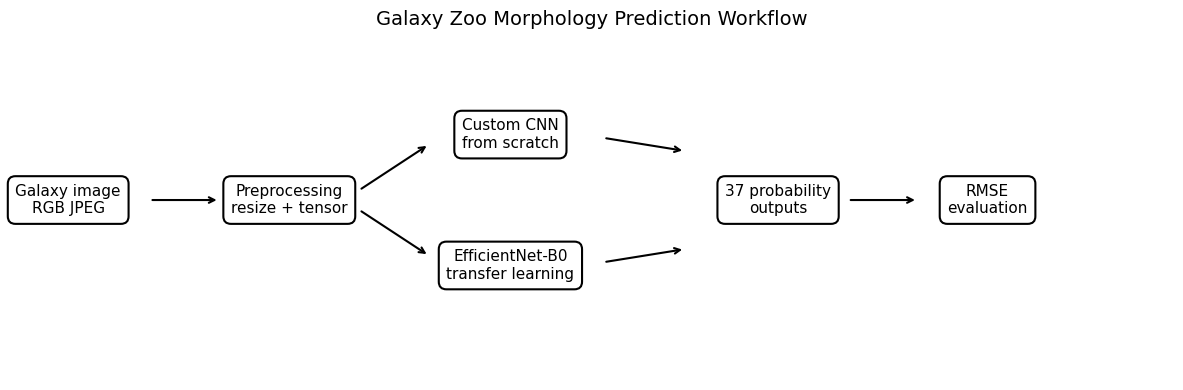

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_method_pipeline.png


In [18]:
def save_method_pipeline(save_path):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")

    boxes = [
        (0.05, 0.55, "Galaxy image\nRGB JPEG"),
        (0.24, 0.55, "Preprocessing\nresize + tensor"),
        (0.43, 0.75, "Custom CNN\nfrom scratch"),
        (0.43, 0.35, "EfficientNet-B0\ntransfer learning"),
        (0.66, 0.55, "37 probability\noutputs"),
        (0.84, 0.55, "RMSE\nevaluation"),
    ]

    for x, y, text in boxes:
        ax.text(
            x, y, text,
            ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.5", linewidth=1.5, facecolor="white")
        )

    arrowprops = dict(arrowstyle="->", linewidth=1.5)
    ax.annotate("", xy=(0.18, 0.55), xytext=(0.12, 0.55), arrowprops=arrowprops)
    ax.annotate("", xy=(0.36, 0.72), xytext=(0.30, 0.58), arrowprops=arrowprops)
    ax.annotate("", xy=(0.36, 0.38), xytext=(0.30, 0.52), arrowprops=arrowprops)
    ax.annotate("", xy=(0.58, 0.70), xytext=(0.51, 0.74), arrowprops=arrowprops)
    ax.annotate("", xy=(0.58, 0.40), xytext=(0.51, 0.36), arrowprops=arrowprops)
    ax.annotate("", xy=(0.78, 0.55), xytext=(0.72, 0.55), arrowprops=arrowprops)

    ax.set_title("Galaxy Zoo Morphology Prediction Workflow", fontsize=14, pad=20)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

method_path = FIG_DIR / "figure_method_pipeline.png"
save_method_pipeline(method_path)
print("Saved:", method_path)


## 19. Figure 3: RMSE learning curves


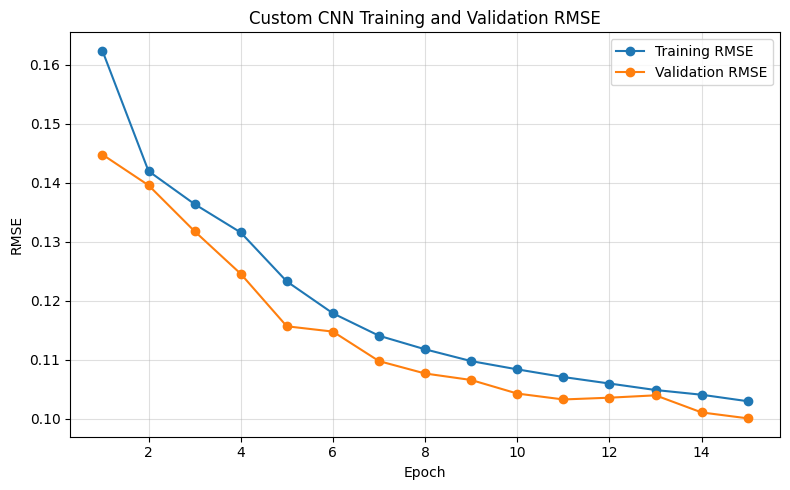

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_custom_cnn_rmse_curve.png


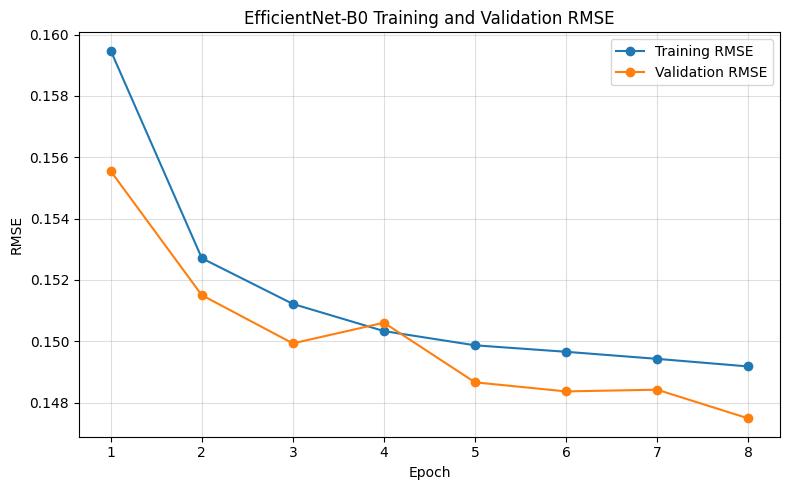

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_efficientnet_rmse_curve.png


In [19]:
def plot_history(history_df, title, save_path):
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_rmse"], marker="o", label="Training RMSE")
    plt.plot(history_df["epoch"], history_df["val_rmse"], marker="o", label="Validation RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

custom_curve_path = FIG_DIR / "figure_custom_cnn_rmse_curve.png"
plot_history(custom_history, "Custom CNN Training and Validation RMSE", custom_curve_path)
print("Saved:", custom_curve_path)

if transfer_history is not None:
    transfer_curve_path = FIG_DIR / "figure_efficientnet_rmse_curve.png"
    plot_history(transfer_history, "EfficientNet-B0 Training and Validation RMSE", transfer_curve_path)
    print("Saved:", transfer_curve_path)
else:
    print("No transfer history available yet. Run the transfer learning training cell first.")


## 20. Figure 4: model comparison bar chart


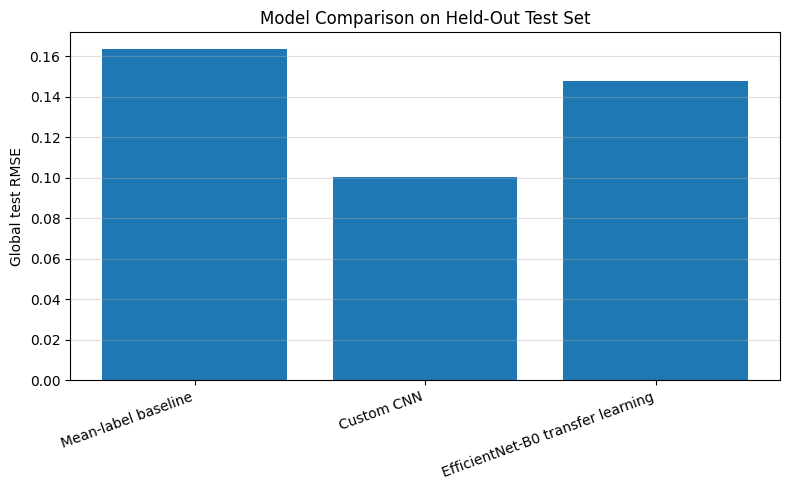

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_model_comparison_rmse.png


In [20]:
comparison_path = FIG_DIR / "figure_model_comparison_rmse.png"

plt.figure(figsize=(8, 5))
plt.bar(results["model"], results["test_rmse"])
plt.ylabel("Global test RMSE")
plt.title("Model Comparison on Held-Out Test Set")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", comparison_path)


## 21. Figure 5: predicted vs true probabilities

This plot checks whether predictions broadly follow the true 37-dimensional probability labels.


Best model: Custom CNN


/tmp/ipykernel_5741/1294994697.py:82: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(use_amp and device.type == "cuda")):


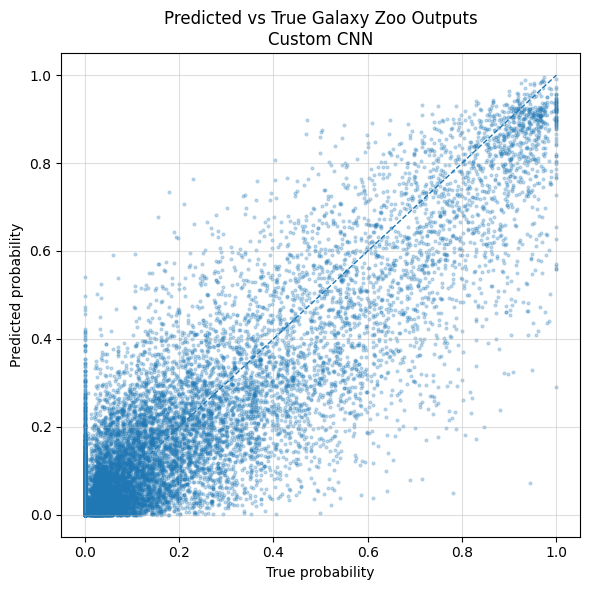

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_predicted_vs_true_probabilities.png


In [21]:
# Use the best model according to test RMSE for the prediction-quality plots.
best_row = results.loc[results["test_rmse"].idxmin()]
best_model_name = best_row["model"]
print("Best model:", best_model_name)

if best_model_name == "EfficientNet-B0 transfer learning":
    plot_model = transfer_model
    plot_loader = transfer_test_loader
else:
    plot_model = custom_model
    plot_loader = custom_test_loader

preds_np, labels_np = collect_predictions(plot_model, plot_loader, DEVICE, max_batches=20)

scatter_path = FIG_DIR / "figure_predicted_vs_true_probabilities.png"

plt.figure(figsize=(6, 6))
plt.scatter(labels_np.flatten(), preds_np.flatten(), s=4, alpha=0.25)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("True probability")
plt.ylabel("Predicted probability")
plt.title(f"Predicted vs True Galaxy Zoo Outputs\n{best_model_name}")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", scatter_path)


## 22. Figure 6: example predicted and true label vectors

This plot shows one test example's true and predicted 37-output vectors.

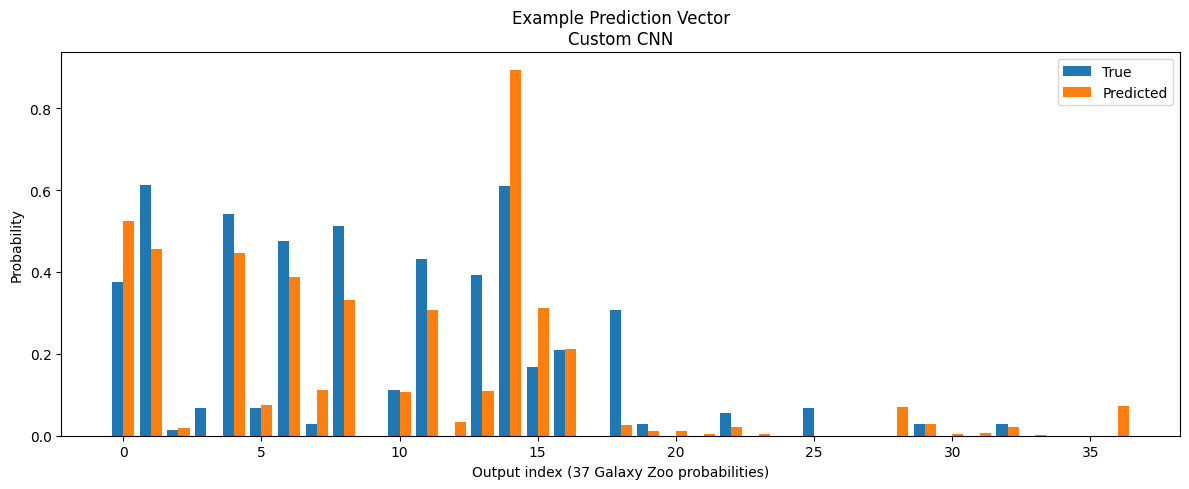

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_single_example_prediction_vector.png


In [22]:
bar_path = FIG_DIR / "figure_single_example_prediction_vector.png"

example_i = 0
x = np.arange(len(label_cols))

plt.figure(figsize=(12, 5))
plt.bar(x - 0.2, labels_np[example_i], width=0.4, label="True")
plt.bar(x + 0.2, preds_np[example_i], width=0.4, label="Predicted")
plt.xlabel("Output index (37 Galaxy Zoo probabilities)")
plt.ylabel("Probability")
plt.title(f"Example Prediction Vector\n{best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", bar_path)


## 23. Target distribution figure

This figure shows the distribution of average label probabilities across the 37 outputs.

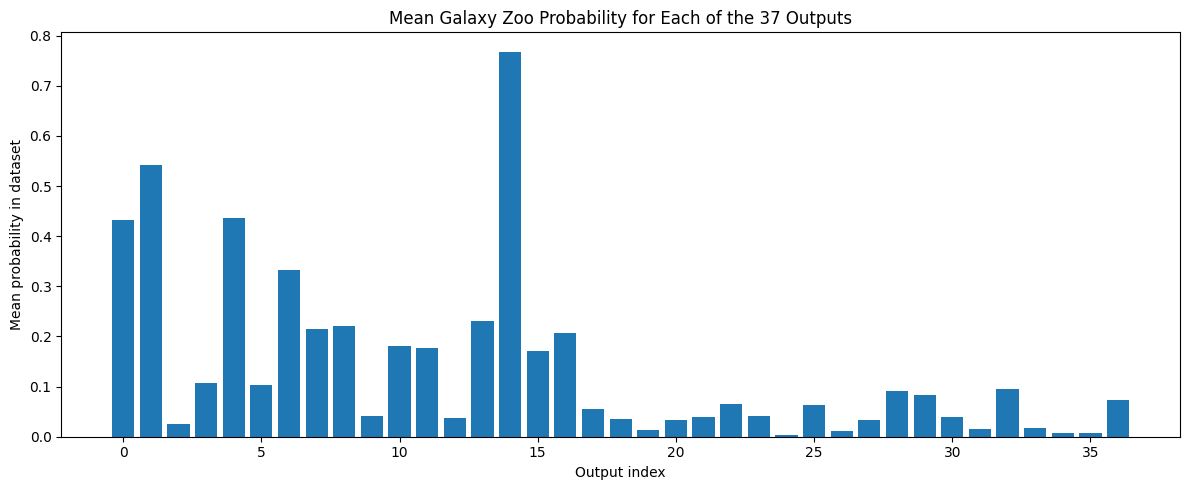

Saved: /content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_mean_label_probabilities.png


In [23]:
label_mean_path = FIG_DIR / "figure_mean_label_probabilities.png"
label_means = df[label_cols].mean(axis=0)

plt.figure(figsize=(12, 5))
plt.bar(np.arange(len(label_cols)), label_means.values)
plt.xlabel("Output index")
plt.ylabel("Mean probability in dataset")
plt.title("Mean Galaxy Zoo Probability for Each of the 37 Outputs")
plt.tight_layout()
plt.savefig(label_mean_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", label_mean_path)


## 24. Print final figure and table paths



In [24]:
print("\nFinal results:")
display(results)

print("\nFigures saved in:", FIG_DIR)
for path in sorted(FIG_DIR.glob("*.png")):
    print(path)

print("\nTables saved in:", TABLE_DIR)
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(path)



Final results:


,model,test_rmse
0,Mean-label baseline,0.163708
1,Custom CNN,0.100299
2,EfficientNet-B0 transfer learning,0.147714



Figures saved in: /content/drive/MyDrive/galaxyzoo/project_outputs/figures
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_custom_cnn_rmse_curve.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_efficientnet_rmse_curve.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_example_galaxy_images.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_mean_label_probabilities.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_method_pipeline.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_model_comparison_rmse.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_predicted_vs_true_probabilities.png
/content/drive/MyDrive/galaxyzoo/project_outputs/figures/figure_single_example_prediction_vector.png

Tables saved in: /content/drive/MyDrive/galaxyzoo/project_outputs/tables
/content/drive/MyDrive/galaxyzoo/project_outputs/tables/custom_cnn_history.csv
/content/drive/MyDrive/galaxyzo